Loading model from /home/U116med/wch_code/cascade/models/prototype_cascade/prototype_kl_loss_0.1_fb_88_v3/best.pth...
Model decoder:  created, param count: 1913515
Found 798 images for analysis.
Evaluating dataset...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 798/798 [00:33<00:00, 23.51it/s]


Hard Samples (Bottom 20%): Avg Dice = 0.4253
Easy Samples (Top 20%):    Avg Dice = 0.9719
Saved analysis plot to ./analysis_results/hard_sample_analysis_kl.png


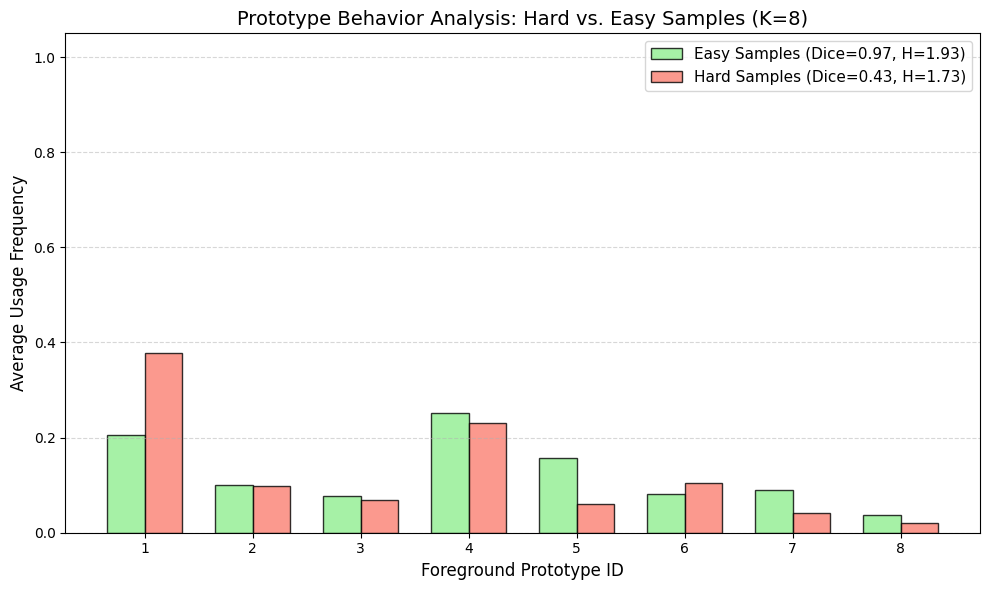

In [7]:
import os
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import entropy
try:
    from lib.networks_prototype import Prototype_CASCADE
except ImportError:
    print("Error: Could not import Prototype_CASCADE.")

from utils.dataloader import test_dataset

def calculate_dice(pred, gt):
    """
    pred: Logits or Probability map
    gt: Binary Ground Truth
    """
    # 轉成機率
    pred = torch.sigmoid(pred)
    # 歸一化 (Min-Max)
    pred = (pred - pred.min()) / (pred.max() - pred.min() + 1e-8)
    
    input_flat = pred.view(-1)
    target_flat = gt.view(-1)
    
    intersection = (input_flat * target_flat).sum()
    dice = (2 * intersection + 1) / (input_flat.sum() + target_flat.sum() + 1)
    return dice.item()

def analyze_hard_samples(cfg):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    os.makedirs(cfg['output_dir'], exist_ok=True)
    
    print(f"Loading model from {cfg['model_path']}...")
    model = Prototype_CASCADE(num_fg=cfg['num_fg'], num_bg=cfg['num_bg']).to(device)
    
    if os.path.exists(cfg['model_path']):
        state_dict = torch.load(cfg['model_path'], map_location=device, weights_only=True)
        model.load_state_dict(state_dict, strict=False)
    else:
        print(f"Error: Model path not found: {cfg['model_path']}")
        return
    model.eval()
    
    # Dataset
    test_loader = test_dataset(cfg['image_root'], cfg['gt_root'], cfg['img_size'])
    num_images = test_loader.size
    print(f"Found {num_images} images for analysis.")
    
    sample_stats = []

    print("Evaluating dataset...")
    with torch.no_grad():
        for i in tqdm(range(num_images)):
            image, gt, name = test_loader.load_data()
            image = image.to(device)
            
            # GT Preprocessing
            gt = np.asarray(gt, np.float32)
            gt /= (gt.max() + 1e-8)
            gt_tensor = torch.from_numpy(gt).unsqueeze(0).unsqueeze(0).to(device).float()

            # Forward
            # model returns: logits_high, similarity_map_high
            logits_high, similarity_map_high = model(image)
            
            # 1. 計算 Dice
            # 根據您的訓練邏輯: (FG - BG) * 10
            # logits_high shape: (B, 2, H, W). Channel 0: BG, Channel 1: FG
            final_pred = (logits_high[:, 1:2, :, :] - logits_high[:, 0:1, :, :]) * 10.0
            
            # Resize if mismatch (Safety check)
            if final_pred.shape[-2:] != gt_tensor.shape[-2:]:
                final_pred = F.interpolate(final_pred, size=gt_tensor.shape[-2:], mode='bilinear')
                
            dice = calculate_dice(final_pred, gt_tensor)
            
            # 2. 分析 Prototype 使用情況
            # 確保 similarity map 尺寸對齊
            if similarity_map_high.shape[-2:] != gt_tensor.shape[-2:]:
                similarity_map_high = F.interpolate(similarity_map_high, size=gt_tensor.shape[-2:], mode='bilinear')

            # 只看前景 Prototype (Index 0 ~ num_fg-1)
            fg_sim_map = similarity_map_high[:, :cfg['num_fg'], :, :] # (1, K, H, W)
            
            # Argmax Assignment
            assignments = torch.argmax(fg_sim_map, dim=1) # (1, H, W)
            
            # Mask Filtering: 只統計 GT 範圍內的像素
            mask = (gt_tensor > 0.5).squeeze(1)
            valid_assignments = assignments[mask]
            
            # 統計分佈
            if valid_assignments.numel() > 0:
                counts = torch.bincount(valid_assignments, minlength=cfg['num_fg']).cpu().numpy()
                probs = counts / counts.sum()
            else:
                # 處理全黑圖或極小目標的情況
                probs = np.zeros(cfg['num_fg'])
            
            sample_stats.append({
                'name': name,
                'dice': dice,
                'proto_dist': probs
            })

    # 3. 排序與分組
    # 按 Dice 從低到高排序 (Low Dice = Hard, High Dice = Easy)
    sample_stats.sort(key=lambda x: x['dice'])
    
    n_samples = len(sample_stats)
    cutoff = int(n_samples * 0.2) # Top/Bottom 20%
    if cutoff == 0: cutoff = 1 # 防止樣本太少
    
    hard_samples = sample_stats[:cutoff]
    easy_samples = sample_stats[-cutoff:]
    
    avg_dice_hard = np.mean([s['dice'] for s in hard_samples])
    avg_dice_easy = np.mean([s['dice'] for s in easy_samples])
    
    print(f"Hard Samples (Bottom 20%): Avg Dice = {avg_dice_hard:.4f}")
    print(f"Easy Samples (Top 20%):    Avg Dice = {avg_dice_easy:.4f}")

    # 4. 聚合分佈
    def aggregate_dist(samples):
        total_dist = np.zeros(cfg['num_fg'])
        valid_count = 0
        for s in samples:
            # 排除全零分佈 (無效樣本)
            if s['proto_dist'].sum() > 0:
                total_dist += s['proto_dist']
                valid_count += 1
        return total_dist / (valid_count + 1e-8)

    hard_dist_agg = aggregate_dist(hard_samples)
    easy_dist_agg = aggregate_dist(easy_samples)
    
    # 5. 計算熵 (Entropy)
    entropy_hard = entropy(hard_dist_agg + 1e-10) # 加小數防止 log(0)
    entropy_easy = entropy(easy_dist_agg + 1e-10)
    
    # 6. 繪圖
    x = np.arange(cfg['num_fg']) + 1
    width = 0.35
    
    plt.figure(figsize=(10, 6))
    
    # 繪製 Easy Samples (綠色)
    plt.bar(x - width/2, easy_dist_agg, width, 
            label=f'Easy Samples (Dice={avg_dice_easy:.2f}, H={entropy_easy:.2f})', 
            color='lightgreen', edgecolor='black', alpha=0.8)
            
    # 繪製 Hard Samples (紅色)
    plt.bar(x + width/2, hard_dist_agg, width, 
            label=f'Hard Samples (Dice={avg_dice_hard:.2f}, H={entropy_hard:.2f})', 
            color='salmon', edgecolor='black', alpha=0.8)
    
    plt.xlabel('Foreground Prototype ID', fontsize=12)
    plt.ylabel('Average Usage Frequency', fontsize=12)
    plt.title(f'Prototype Behavior Analysis: Hard vs. Easy Samples (K={cfg["num_fg"]})', fontsize=14)
    plt.xticks(x)
    plt.ylim(0, 1.05)
    plt.legend(fontsize=11)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    # 標註數值
    def add_labels(rects):
        for rect in rects:
            height = rect.get_height()
            plt.text(rect.get_x() + rect.get_width()/2., height + 0.01,
                     f'{height:.2f}', ha='center', va='bottom', fontsize=9)
    
    # add_labels(plt.gca().containers[0]) # Easy
    # add_labels(plt.gca().containers[1]) # Hard (如果圖太亂可以註解掉)

    plt.tight_layout()
    save_path = os.path.join(cfg['output_dir'], 'hard_sample_analysis_kl.png')
    plt.savefig(save_path, dpi=300)
    print(f"Saved analysis plot to {save_path}")

if __name__ == '__main__':
    config = {
        # 請修改為您的 K=8 模型路徑
        'model_path': '/home/U116med/wch_code/cascade/models/prototype_cascade/prototype_kl_loss_0.1_fb_88_v3/best.pth',
        
        # 數據集路徑
        'image_root': '/home/U116med/data/polyp/TestDataset/test/images/',
        'gt_root': '/home/U116med/data/polyp/TestDataset/test/masks/',
        
        'img_size': 352,
        'num_fg': 8,
        'num_bg': 8,
        
        'output_dir': './analysis_results/'
    }
    analyze_hard_samples(config)